# Hydrogen bound-free continuum demo

The 0D slab model emerges **both** the bound-bound (b-b) line spectrum and the
bound-free (b-f) recombination continuum. `SE_to_slab_0D_` returns the pair
`(bb_con, bf_con)`; this notebook plots the H line peaks together with the b-f
continua and the Planck function at $T_e$, reproducing the reference figure of
`notebooks_local/bf_continuum/test_bf_Continuum.ipynb`.

This notebook is **generated** from `build_notebook.py` in this folder.
Re-run the script after any change to the SE / Cloud / Atomic APIs.


## Formulae

Wavelength-base coefficients (`spectra.Atomic.emisivity` / `extinction`).

**Bound-bound line** (per transition, profile $\phi$ normalized to
$\int\phi\,d\lambda = 1$):

$$j^{bb} = \frac{h\nu}{4\pi} A_{ji} N_j, \qquad
  \alpha^{bb} = \frac{h\nu}{4\pi}\,(N_i B_{ij} - N_j B_{ji}).$$

**Bound-free continuum** (per continuum, photoelectron energy
$\varepsilon = h\nu - \chi$ with edge $\chi = h f_0$):

$$j_\lambda^{bf} = \frac{h\nu}{4\pi}\,\sigma_\nu^{fb}\,f(\varepsilon)v\,
                   N_{I+1} N_e\,\frac{d\varepsilon}{d\nu}\cdot\frac{c}{\lambda^2},
  \qquad
  \alpha_\lambda^{bf} = \sigma_\nu^{bf} N_i\,(1 - e^{-h\nu/k_B T_e}),$$

with the Milne relation
$\sigma_\nu^{fb} = \frac{g_i}{2 g_k}\frac{(h\nu)^2}{m_e c^2\,\varepsilon}\sigma_\nu^{bf}$,
the Maxwellian recombination flux
$f(\varepsilon)v = 8\pi m_e\,\varepsilon\,(2\pi m_e k_B T_e)^{-3/2}
e^{-\varepsilon/k_B T_e}$, and $d\varepsilon/d\nu = h$. The photoionization cross
section $\sigma_\nu^{bf}$ comes from `atom.PI.alpha_interp`. The $\varepsilon$
factors cancel analytically, so $j_\lambda^{bf}$ stays finite at the edge.

**Slab radiative transfer** (per wavelength), with source function
$S = j/\alpha$, optical depth $\tau = d\,\alpha$, and emergent intensity

$$I_\lambda = I_\lambda^{(0)} e^{-\tau} + S\,(1 - e^{-\tau}).$$


## Setup


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spectra.Atomic import LTELib
from spectra.Function.SEquil import SELib
from spectra.Function.SlabModel import CloudModel
from spectra.Struct import Atmosphere, Atom, Radiation

# Parameters of the reference notebook.
NLEVEL = 20
TE = 6000.0       # electron temperature [K]
NE = 1.0e11       # electron density [cm^-3]
JFACTOR = 0.5     # scaling of the incident solar radiation
VT = 5.0e5        # microturbulent velocity [cm/s] (5 km/s; the prototype's
                  # Vt=5.0 cm/s was a typo — corrected here. Affects only line
                  # widths, not the plotted peaks or the Vt-independent continua.)
DEPTH = 1.0e3 * 1.0e5  # 1000 km slab in cm

# Theoretical hydrogen atom: alpha_interp is filled by the degenerate-n
# photoionization cross section, so the b-f continuum matches the prototype.
atom = Atom.init_theoretical_hydrogen_atom_(nLevel=NLEVEL)

# slab with Nh=0: cal_SE_with_Ne_Te_ derives the H density consistent with
# (Ne, Te) and writes it back into atmos.Nh / SE_con.Nh.
atmos = Atmosphere.Atmosphere0D(Nh=0, Ne=NE, Te=TE, Vd_obs=0.0, Vd_sun=0.0, Vt=VT)

radiation = Radiation.init_Radiation_()
radiation.solar[1, :] *= JFACTOR

SE_con, _ = SELib.cal_SE_with_Ne_Te_(atom, atmos, radiation, None)


## Slab spectrum

`SE_to_slab_0D_` returns the line container and the continuum container.


In [2]:
bb_con, bf_con = CloudModel.SE_to_slab_0D_(atom, atmos, SE_con, depth=DEPTH)


def line_peak_intensity(bb):
    # peak emergent intensity of each line, taken at its strongest |tau| sample.
    Ipeak = np.zeros(bb.w0.size)
    for i in range(bb.w0.size):
        i1, i2 = bb.Line_mesh_idxs[i, 0], bb.Line_mesh_idxs[i, 1]
        i0 = np.abs(bb.tau_1D[i1:i2]).argmax()
        Ipeak[i] = bb.prof_1D[i1:i2][i0]
    return Ipeak


Ipeak = line_peak_intensity(bb_con)
print(f"nLine = {bb_con.w0.size},  nCont = {bf_con.w0.size}")
print(f"bf_con.prof shape = {bf_con.prof.shape}  (nCont, nWavelength)")


nLine = 171,  nCont = 19
bf_con.prof shape = (19, 41)  (nCont, nWavelength)


## Plot — line peaks, b-f continua, and Planck at $T_e$


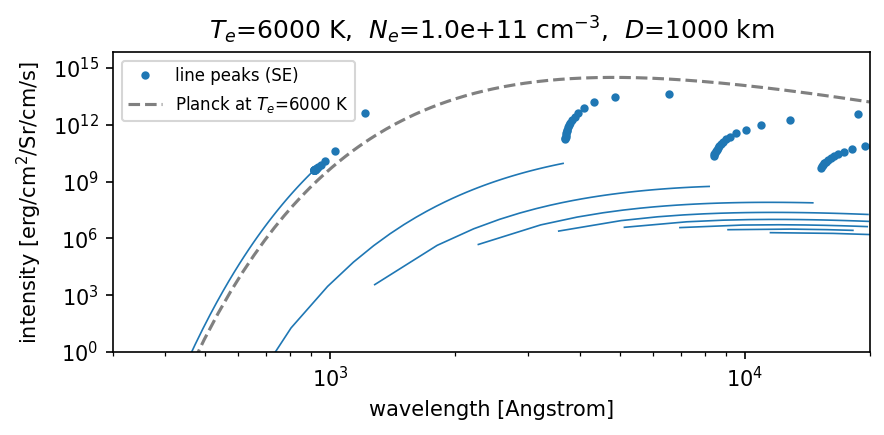

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=150)

wrange = [300.0, 20000.0]  # Angstrom

# b-b line peaks (SE)
w0_ang = bb_con.w0 * 1.0e8
ii = (w0_ang >= wrange[0]) & (w0_ang <= wrange[1])
ax.plot(w0_ang[ii], Ipeak[ii], ".", label="line peaks (SE)", color="C0")

# b-f continua: emergent intensity per continuum on its wavelength mesh
for nl in range(bf_con.w0.size):
    wl_ang = bf_con.wl[nl, :] * 1.0e8
    jj = (wl_ang >= wrange[0]) & (wl_ang <= wrange[1])
    if jj.sum() > 1:
        ax.plot(wl_ang[jj], bf_con.prof[nl, jj], color="C0", lw=0.8)

# Planck at Te
wlp = np.linspace(wrange[0], wrange[1], 500)
planck = LTELib.planck_cm_(wlp / 1.0e8, TE)
ax.plot(wlp, planck, "--", color="gray", label=f"Planck at $T_e$={TE:.0f} K")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*wrange)
ax.set_ylim(1.0, None)
ax.set_xlabel("wavelength [Angstrom]")
ax.set_ylabel(r"intensity [erg/cm$^2$/Sr/cm/s]")
ax.set_title(
    rf"$T_e$={TE:.0f} K,  $N_e$={NE:.1e} cm$^{{-3}}$,  $D$={DEPTH / 1.0e5:.0f} km"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Verification.**

- Each b-f continuum rises toward its ionization edge (short-wavelength side)
  and the Balmer / Paschen / ... edges appear as the characteristic sawtooth.
- Optically-thick continua approach the **Planck** curve at $T_e$ (the source
  function $S = j/\alpha \to B_\lambda(T_e)$ in LTE), so the b-f envelope tracks
  the gray dashed line where $\tau \gtrsim 1$.
- The line peaks sit on top of the continuum, as in the reference notebook.

The task's regression harness (`docs/tasks/012-bf-coutinuum/regression_harness.py`)
checks these `bf_con` arrays against the original prototype and agrees to
~0.18% (set by the `alpha_interp` vs gaunt-$\sigma_{bf}$ difference).
